# **Bachelor Thesis Model Kernel**

**Author:** Marek Šugár

Faculty of Mathematics, Physics and Informatics Comenius University in Bratislava

In [118]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error

# ML Stuff
from sklearn.neighbors import KNeighborsRegressor

In [129]:
# General connection to the DB with data
StockDataDatabase = sqlite3.connect("StockData.db")

# Index Data (NASDAQ and S&P 500)
NASDAQ = pd.read_sql("SELECT * FROM Indexes WHERE IndexName='NASDAQ'", con=StockDataDatabase, parse_dates=["Date"])
SP500 = pd.read_sql("SELECT * FROM Indexes WHERE IndexName='S&P 500'", con=StockDataDatabase, parse_dates=["Date"])

# Stocks' Tickers
tickers = pd.read_sql("SELECT * FROM Tickers", con=StockDataDatabase)

# Market Indicators
VIX = pd.read_sql("SELECT * FROM MarketIndicators WHERE Indicator='VIX'", con=StockDataDatabase, parse_dates=["Date"])
bond_13_Week = pd.read_sql("SELECT * FROM MarketIndicators WHERE Indicator='13-Week Treasury'", con=StockDataDatabase, parse_dates=["Date"])
bond_5_Year = pd.read_sql("SELECT * FROM MarketIndicators WHERE Indicator='5-Year Treasury'", con=StockDataDatabase, parse_dates=["Date"])

# Currency exchange rates
EUR_USD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='EUR/USD'", con=StockDataDatabase, parse_dates=["Date"])
JPY_USD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='JPY/USD'", con=StockDataDatabase, parse_dates=["Date"])
GBP_USD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='GBP/USD'", con=StockDataDatabase, parse_dates=["Date"])
USD_CHF = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='USD/CHF'", con=StockDataDatabase, parse_dates=["Date"])
AUD_USD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='AUD/USD'", con=StockDataDatabase, parse_dates=["Date"])
USD_CAD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='USD/CAD'", con=StockDataDatabase, parse_dates=["Date"])
NZD_USD = pd.read_sql("SELECT * FROM CurrencyExchange WHERE Currencies='NZD/USD'", con=StockDataDatabase, parse_dates=["Date"])

In [131]:
# Now we perform shifts in the data, so we obtain lagged features for the prediction
initial_columns = ["Open", "Close", "Volume"]
historic_columns = []
for shift in range(1, 5):
    for column in initial_columns:
        VIX[f"{column}_{shift}"] = VIX[f"{column}"].shift(shift)
        historic_columns.append(f"{column}_{shift}")

VIX = VIX.dropna().reset_index(drop=True)

# **k-Nearest Neighbours (KNN) Algorithm**

In [149]:
performance_tracker = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-18'", con=StockDataDatabase, parse_dates=["Date"])
    Stock_Data["Target"] = Stock_Data["Close"].shift(-1)
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    VIX_Training = VIX[historic_columns]

    training_length = 100 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []

    MAPEs = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        Training_Features = VIX_Training.iloc[window_start:window_start+training_length]
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = VIX_Training.iloc[window_start+training_length:window_start+training_length+prediction_length]
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = KNeighborsRegressor(n_neighbors=3)

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
    performance_tracker[ticker] = MAPEs.copy()

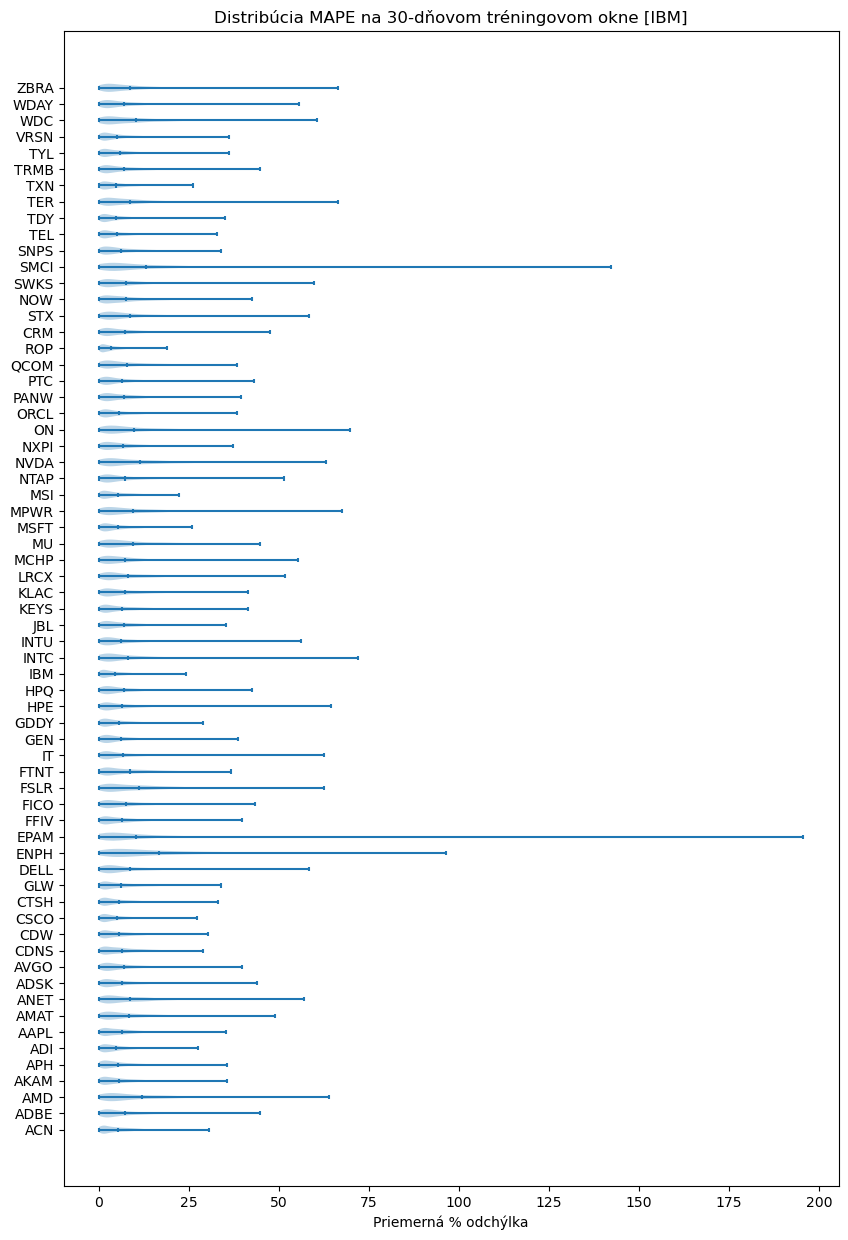

In [172]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker.values(), showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), performance_tracker.keys())

plt.title("Distribúcia MAPE na 30-dňovom tréningovom okne [IBM]")

plt.show()